<a href="https://colab.research.google.com/github/NairMpc/DataScience/blob/main/Assignment_16_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment-16
System Recommendation

Data Description: anime.csv

Unique ID of each anime.
Anime title.
Anime broadcast type, such as TV, OVA, etc.
anime genre.
The number of episodes of each anime.
The average rating for each anime compared to the number of users who gave ratings.


Number of community members for each anime.
Objective:
The objective of this assignment is to implement a recommendation system using cosine similarity on an anime dataset.
Dataset:
Use the Anime Dataset which contains information about various anime, including their titles, genres, No.of episodes and user ratings etc.

Tasks:

Data Preprocessing:

Load the dataset into a suitable data structure (e.g., pandas DataFrame).
Handle missing values, if any.
Explore the dataset to understand its structure and attributes.

Feature Extraction:

Decide on the features that will be used for computing similarity (e.g., genres, user ratings).
Convert categorical features into numerical representations if necessary.
Normalize numerical features if required.

Recommendation System:

Design a function to recommend anime based on cosine similarity.
Given a target anime, recommend a list of similar anime based on cosine similarity scores.
Experiment with different threshold values for similarity scores to adjust the recommendation list size.
Analyze the performance of the recommendation system and identify areas of improvement.

Interview Questions:
1. Can you explain the difference between user-based and item-based collaborative filtering?
2. What is collaborative filtering, and how does it work?



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

### Data Preprocessing: Loading the dataset

In [ ]:
try:
    df = pd.read_csv('anime.csv')
    print("Dataset loaded successfully.")
    display(df.head())
except FileNotFoundError:
    print("Error: anime.csv not found. Please ensure the file is uploaded to the Colab environment.")

Dataset loaded successfully.


,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [ ]:
df.columns

Index(['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members'], dtype='object')

In [ ]:
print(df.shape)

(12294, 7)


#### The dataset contains 12,294 anime records and 7 columns.
Each row represents one anime entry.

### Exploring Dataset Structure and Summary Statistics

In [ ]:
# Get a concise summary of the DataFrame, including data types and non-null values
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB
None


In [ ]:
# Get descriptive statistics for numerical columns
display(df.describe())

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [ ]:
# Check duplicate rows
print(df.duplicated().sum())

0


In [ ]:
# Remove duplicates if present
df.drop_duplicates(inplace=True)

#### Duplicate records are checked because they can bias similarity calculations and affect recommendation quality.

## Interpretation of Dataset Columns
`anime_id`
A unique identification number assigned to each anime.
It acts as the primary key and helps distinguish one anime from another.

`name`
The title/name of the anime.
This column is important for displaying recommendations to users.

`genre`
Contains the genres associated with each anime such as Action, Comedy, Drama, Romance, etc.
Multiple genres are usually separated by commas, so this column requires preprocessing before similarity calculation.

`type`
Represents the format or broadcast category of the anime, such as TV, Movie, OVA, ONA, or Special.
Since it is categorical data, its unique values should be examined and encoded into numerical form.

`episodes`
Indicates the total number of episodes in the anime.
This column is stored as an object type because some entries may contain non-numeric values like “Unknown”.
Therefore, it must be cleaned and converted into numeric format.

`rating`
Shows the average user rating of the anime.
It is a continuous numerical feature and plays an important role in measuring anime similarity.

`members`
Represents the number of users/community members who added the anime to their watchlist or favorites.
This indicates the popularity of the anime.

#### Further Inspection Required

To understand the dataset more clearly:

The type column should be checked for unique categories and their frequency distribution.

The episodes column should be inspected for invalid or unknown values before numerical conversion.

The genre column should be analyzed carefully because it contains multiple values in a single field.

object columns are

 1   name      12294 non-null  object

 2   genre     12232 non-null  object

 3   type      12269 non-null  object

 4   episodes  12294 non-null  object  

 let see its nature

In [ ]:
object_columns = df.select_dtypes(include=['object'])
display(object_columns.head())

,name,genre,type,episodes
0,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64
2,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51
3,Steins;Gate,"Sci-Fi, Thriller",TV,24
4,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51


In [ ]:
# nummber of unique values in object_columns
for column in object_columns.columns:
    unique_values = object_columns[column].nunique()
    print(f"Unique values in '{column}':")
    print(unique_values)
    print()

Unique values in 'name':
12292

Unique values in 'genre':
3264

Unique values in 'type':
6

Unique values in 'episodes':
187



### Interpretation of Unique Values
The name column contains mostly unique anime titles and acts as an identifier column.

The genre column shows 3264 unique values because each row contains combinations of multiple genres (e.g., “Action, Comedy, Drama”). Therefore, the count represents unique genre combinations rather than individual genres.

The type column contains only 6 unique categories, making it suitable for one-hot encoding.

The episodes column contains 187 unique values because anime series vary widely in episode count, and some entries originally contained non-numeric values such as “Unknown”

In [ ]:
print("Unique values in 'type' column:")
print(df['type'].value_counts())

print("\nUnique values in 'episodes' column:")
print(df['episodes'].value_counts())

Unique values in 'type' column:
type
TV         3787
OVA        3311
Movie      2348
Special    1676
ONA         659
Music       488
Name: count, dtype: int64

Unique values in 'episodes' column:
episodes
1       5677
2       1076
12       816
13       572
26       514
        ... 
1006       1
162        1
132        1
141        1
125        1
Name: count, Length: 187, dtype: int64


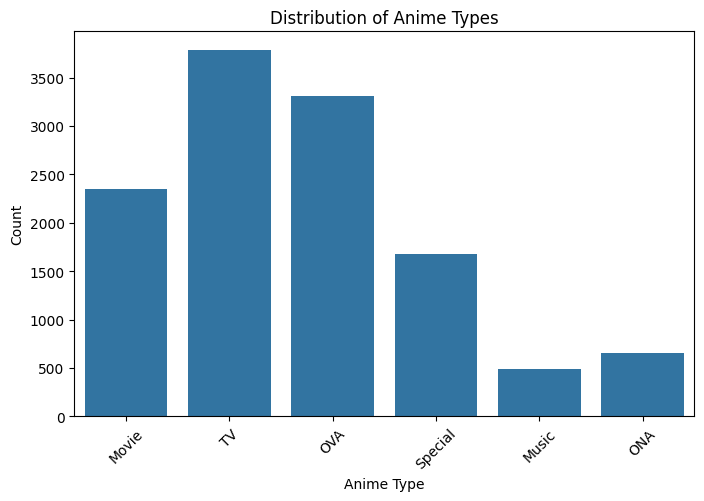

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='type', data=df)

plt.title("Distribution of Anime Types")
plt.xlabel("Anime Type")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()

### episodes column:
The value_counts() for 'episodes' shows that '1' is by far the most frequent value, followed by 2, 12, 13, 26, and so on. The key observation is that while many values are numeric, the presence of 187 unique values for what should ideally be integers strongly suggests the presence of non-numeric entries like 'Unknown', as previously inferred from its 'object' Dtype. These non-numeric entries will need to be identified and handled (e.g., converted to NaN and then imputed or dropped) before the column can be converted to a numeric type (e.g., int or float) for quantitative analysis or feature scaling.

In [ ]:
# convert 'episodes' to numeric by converting any nonnumeric to NaN
#errors='coerce'- Numeric values → remain numeric: Non-numeric values like "Unknown" → become NaN
df['episodes'] = pd.to_numeric(df['episodes'], errors='coerce')

# Check the updated datatype and missing values
print(df['episodes'].dtype)
print(df['episodes'].isnull().sum())



float64
340


### means:

episodes has successfully been converted from object to numeric type (float64)
340 values became NaN because they were non-numeric entries such as "Unknown" or invalid values

So now the column is ready for numerical analysis, but the missing values should be handled next.

In [ ]:
# Fill missing episode values with median
df['episodes'].fillna(df['episodes'].median(), inplace=True)
print(df['episodes'].isnull().sum())

0


Median imputation was used for the episodes column because episode counts may contain extreme values, and median is less affected by outliers compared to mean.

### Log Transformation of the episodes Column

The episodes column showed a highly right-skewed distribution, where most anime had a small number of episodes while a few anime had extremely large episode counts.

To reduce this skewness and prevent very large values from dominating similarity calculations, a logarithmic transformation was applied using:

In [ ]:
# Apply logarithmic transformation to reduce skewness in episode counts
df['episodes_log'] = np.log1p(df['episodes'])

In [ ]:
display(df.head())

,anime_id,name,genre,type,episodes,rating,members,episodes_log
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1.0,9.37,200630,0.693147
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64.0,9.26,793665,4.174387
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51.0,9.25,114262,3.951244
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24.0,9.17,673572,3.218876
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51.0,9.16,151266,3.951244


Keeping both columns is useful because:

episodes → original interpretable values

episodes_log → transformed values for modeling/similarity

### Visualizing the Distribution Before and After Log Transformation

First, the original episodes column is visualized to examine the actual distribution of episode counts and identify skewness or extreme values. Since the distribution is highly right-skewed, a logarithmic transformation is applied to create the episodes_log feature. The transformed distribution is then visualized again to observe how the skewness has been reduced and the data has become more balanced for similarity computation.

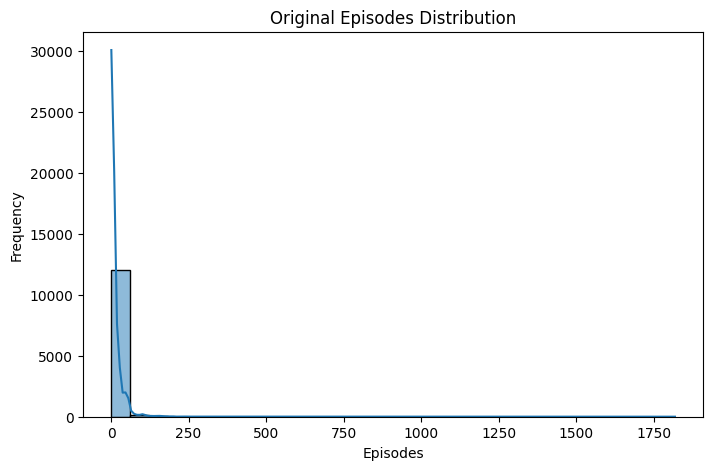

In [ ]:
# Visualize the original distribution of episode counts to check skewness and outliers
plt.figure(figsize=(8,5))

sns.histplot(df['episodes'], bins=30, kde=True)

plt.title('Original Episodes Distribution')
plt.xlabel('Episodes')
plt.ylabel('Frequency')

plt.show()

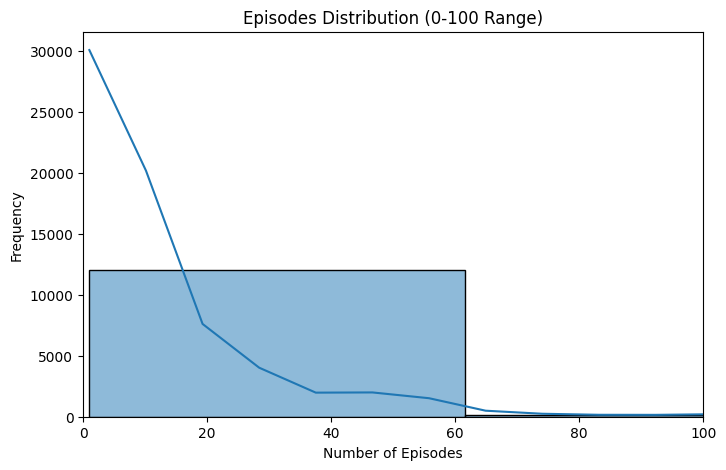

In [ ]:
# Limit the x-axis to 0–100 episodes to better visualize where most anime are concentrated
plt.figure(figsize=(8,5))

sns.histplot(df['episodes'], bins=30, kde=True)

plt.xlim(0, 100)

plt.title('Episodes Distribution (0-100 Range)')
plt.xlabel('Number of Episodes')
plt.ylabel('Frequency')

plt.show()

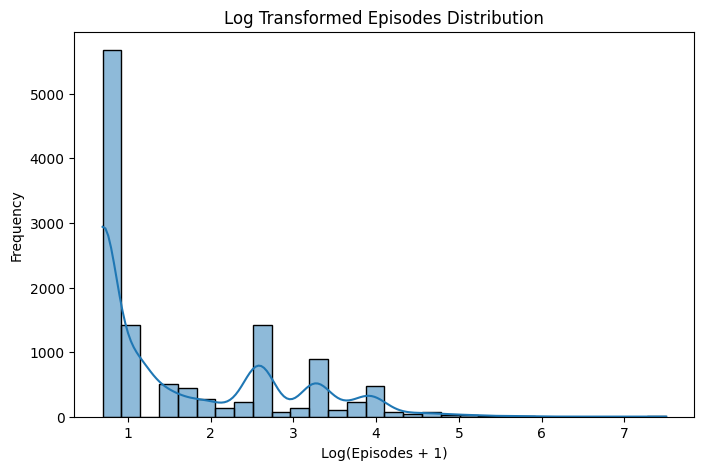

In [ ]:
# Visualize the log-transformed episode distribution after reducing skewness
plt.figure(figsize=(8,5))

sns.histplot(df['episodes_log'], bins=30, kde=True)

plt.title('Log Transformed Episodes Distribution')
plt.xlabel('Log(Episodes + 1)')
plt.ylabel('Frequency')

plt.show()

### Interpretation of histograms

The first histogram shows the overall distribution of episode counts, which is highly right-skewed due to a few anime with very large numbers of episodes.

The second histogram, limited to the 0–100 range, provides a clearer view of where most anime are concentrated.

The third histogram shows that after logarithmic transformation, the distribution becomes more balanced and less skewed, making it more suitable for cosine similarity calculations

In [ ]:
df.isnull().sum()

,0
anime_id,0
name,0
genre,62
type,25
episodes,0
rating,230
members,0
episodes_log,0


### Since the 'type' column is categorical, I will impute its missing values using the mode (most frequent category), which is 'TV'.

In [ ]:
df['type'].fillna(df['type'].mode()[0], inplace=True)
print(df['type'].isnull().sum())

0


### Imputing Missing Values in 'rating' Column
Since 'rating' is a continuous variable, and to minimize the impact of potential outliers, I will impute its missing values with the median of the column.

In [ ]:
df['rating'].fillna(df['rating'].median(), inplace=True)
print(df['rating'].isnull().sum())

0


In [ ]:
df.isnull().sum()

,0
anime_id,0
name,0
genre,62
type,0
episodes,0
rating,0
members,0
episodes_log,0


In [ ]:
#view random values of 'genre'
df['genre'].sample(10)

,genre
10820,Drama
2518,"Action, Mystery, Sci-Fi, Thriller"
11059,"Action, Fantasy"
6382,"Adventure, Fantasy, Kids"
9970,"Action, Drama, Military, Seinen"
7528,"Action, Historical, Samurai, Supernatural"
4400,Drama
8413,"Action, Adventure, Mecha, Sci-Fi, Shounen"
7998,"Comedy, Dementia"
338,"Romance, School, Shoujo, Slice of Life"


### Imputing Missing Values in 'genre' Column
Since the 'genre' column is categorical and can have multiple values, and considering that a missing value might indicate an unspecified genre, I will impute the missing values with the string 'Unknown'. This way, missing genres will not be conflated with existing genres and can be treated as a separate category if needed for the recommendation system.

In [ ]:
df['genre'].fillna('Unknown', inplace=True)
print(df['genre'].isnull().sum())

0


In [ ]:
# Apply logarithmic transformation to reduce skewness in member counts
df['members_log'] = np.log1p(df['members'])

# Display transformed values
df[['members', 'members_log']].head()

,members,members_log
0,200630,12.209223
1,793665,13.584418
2,114262,11.646258
3,673572,13.420352
4,151266,11.926802


The members column is highly right-skewed because a few anime are extremely popular while most have smaller community sizes.

Logarithmic transformation is applied to:

- reduce skewness

- compress extreme values

- prevent highly popular anime from dominating similarity calculations

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   anime_id      12294 non-null  int64  
 1   name          12294 non-null  object 
 2   genre         12294 non-null  object 
 3   type          12294 non-null  object 
 4   episodes      12294 non-null  float64
 5   rating        12294 non-null  float64
 6   members       12294 non-null  int64  
 7   episodes_log  12294 non-null  float64
 8   members_log   12294 non-null  float64
dtypes: float64(4), int64(2), object(3)
memory usage: 864.6+ KB


### Encoding Categorical Features

The genre and type columns contain categorical information that must be converted into numerical format before computing cosine similarity.

The genre column contains multiple genres for each anime, so Multi-Label Binarization is used to create separate binary columns for each genre.

The type column contains single categorical values such as TV, Movie, and OVA, so One-Hot Encoding is applied using pd.get_dummies().

In [ ]:
#ImportMultiLabelBinarizer() and create instance
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
display(mlb)

MultiLabelBinarizer()

In [ ]:
# Convert genre strings into lists
df['genre'] = df['genre'].apply(lambda x: [g.strip() for g in x.split(',')])

genre_matrix = mlb.fit_transform(df['genre'])

genre_encoded = pd.DataFrame(
    genre_matrix,
    columns=mlb.classes_,
    index=df.index
)

Since one anime can belong to multiple genres simultaneously, One-Hot Encoding alone is insufficient.

MultiLabelBinarizer converts each individual genre into separate binary columns indicating whether an anime belongs to that genre or not.

After encoding , a value of:

- 1 indicates the anime belongs to that genre

- 0 indicates absence of that genre

In [ ]:
genre_encoded.head()

,Action,Adventure,Cars,Comedy,Dementia,Demons,Drama,Ecchi,Fantasy,Game,...,Slice of Life,Space,Sports,Super Power,Supernatural,Thriller,Unknown,Vampire,Yaoi,Yuri
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,1,1,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
type_encoded = pd.get_dummies(
    df['type'],
    prefix='type',
    dtype=int
)

In [ ]:
type_encoded.head()

,type_Movie,type_Music,type_ONA,type_OVA,type_Special,type_TV
0,1,0,0,0,0,0
1,0,0,0,0,0,1
2,0,0,0,0,0,1
3,0,0,0,0,0,1
4,0,0,0,0,0,1


In [ ]:
# Combine encoded features with original dataframe
anime_df = pd.concat([df, genre_encoded, type_encoded], axis=1)

# Display encoded dataframe
display(anime_df.head())

,anime_id,name,genre,type,episodes,rating,members,episodes_log,members_log,Action,...,Unknown,Vampire,Yaoi,Yuri,type_Movie,type_Music,type_ONA,type_OVA,type_Special,type_TV
0,32281,Kimi no Na wa.,"[Drama, Romance, School, Supernatural]",Movie,1.0,9.37,200630,0.693147,12.209223,0,...,0,0,0,0,1,0,0,0,0,0
1,5114,Fullmetal Alchemist: Brotherhood,"[Action, Adventure, Drama, Fantasy, Magic, Mil...",TV,64.0,9.26,793665,4.174387,13.584418,1,...,0,0,0,0,0,0,0,0,0,1
2,28977,Gintama°,"[Action, Comedy, Historical, Parody, Samurai, ...",TV,51.0,9.25,114262,3.951244,11.646258,1,...,0,0,0,0,0,0,0,0,0,1
3,9253,Steins;Gate,"[Sci-Fi, Thriller]",TV,24.0,9.17,673572,3.218876,13.420352,0,...,0,0,0,0,0,0,0,0,0,1
4,9969,Gintama&#039;,"[Action, Comedy, Historical, Parody, Samurai, ...",TV,51.0,9.16,151266,3.951244,11.926802,1,...,0,0,0,0,0,0,0,0,0,1


### Cleaning Anime Names

Anime titles may contain inconsistent capitalization, extra spaces,
or special characters at the beginning/end of strings.

To improve recommendation lookup reliability and avoid matching errors,
anime names are cleaned by:

- converting to lowercase

- removing leading/trailing spaces

- removing unnecessary special characters from the start and end

In [ ]:
# Clean anime names for lookup/search purposes
import re

# anime_df['clean_name'] = (
#     anime_df['name']
#     .str.lower()
#     .str.strip()
#     .str.replace(
#         r'^[^a-z0-9]+|[^a-z0-9]+$',
#         '',
#         regex=True
#     )
# )
anime_df['clean_name'] = (
    anime_df['name']
    .str.lower()
    .str.strip()
    .str.replace(r'[^a-z\s]', '', regex=True)   # remove special chars
    .str.replace(r'\s+', ' ', regex=True)          # normalize multiple spaces
    .str.strip()
)

# Preview cleaned names
display(
    anime_df[['name', 'clean_name']].sample(10)
)

,name,clean_name
6336,Catman Specials,catman specials
7064,Super Mario Brothers: Peach-hime Kyuushutsu Da...,super mario brothers peachhime kyuushutsu dais...
7475,Meitantei Gordon,meitantei gordon
3739,Mai-HiME: Kuro no Mai/Saigo no Bansan,maihime kuro no maisaigo no bansan
2238,Kuroshitsuji Recap,kuroshitsuji recap
9669,Naniwa Yuukyouden: Kyouretsu! Ana ga Attara Ir...,naniwa yuukyouden kyouretsu ana ga attara iret...
4825,Ys,ys
6288,Hakushon Daimaou,hakushon daimaou
10204,Shiden Pilot,shiden pilot
8271,Bubaga,bubaga


### Feature Selection

After encoding the categorical features, the relevant numerical and encoded columns are selected to create the final feature matrix for cosine similarity computation. Only meaningful features related to anime characteristics and popularity are included in the recommendation system.

##### The following features are selected for computing cosine similarity:

rating → Represents the average user rating of the anime.

episodes_log → Represents the log-transformed episode count to reduce skewness.

members_log → Represents the log-transformed popularity of the anime based on community members.

Encoded genre columns → Capture the thematic similarity between anime.

Encoded type columns → Represent the anime format such as TV, Movie, or OVA.


These features are chosen because they describe the content, popularity, and characteristics of anime, making them suitable for measuring similarity in a content-based recommendation system.

In [ ]:
# Select features for similarity computation
feature_columns = (
    ['rating', 'episodes_log', 'members_log'] +
    list(genre_encoded.columns) +
    list(type_encoded.columns)
)
feature_columns

['rating',
 'episodes_log',
 'members_log',
 'Action',
 'Adventure',
 'Cars',
 'Comedy',
 'Dementia',
 'Demons',
 'Drama',
 'Ecchi',
 'Fantasy',
 'Game',
 'Harem',
 'Hentai',
 'Historical',
 'Horror',
 'Josei',
 'Kids',
 'Magic',
 'Martial Arts',
 'Mecha',
 'Military',
 'Music',
 'Mystery',
 'Parody',
 'Police',
 'Psychological',
 'Romance',
 'Samurai',
 'School',
 'Sci-Fi',
 'Seinen',
 'Shoujo',
 'Shoujo Ai',
 'Shounen',
 'Shounen Ai',
 'Slice of Life',
 'Space',
 'Sports',
 'Super Power',
 'Supernatural',
 'Thriller',
 'Unknown',
 'Vampire',
 'Yaoi',
 'Yuri',
 'type_Movie',
 'type_Music',
 'type_ONA',
 'type_OVA',
 'type_Special',
 'type_TV']

In [ ]:
# Create final feature matrix
features_df = anime_df[feature_columns]

# Display selected features
display(features_df.head())

,rating,episodes_log,members_log,Action,Adventure,Cars,Comedy,Dementia,Demons,Drama,...,Unknown,Vampire,Yaoi,Yuri,type_Movie,type_Music,type_ONA,type_OVA,type_Special,type_TV
0,9.37,0.693147,12.209223,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
1,9.26,4.174387,13.584418,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
2,9.25,3.951244,11.646258,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,9.17,3.218876,13.420352,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,9.16,3.951244,11.926802,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1


### Final Null Check

In [ ]:
features_df.isnull().sum().sum()

np.int64(0)

### Feature Scaling

The final feature matrix contains both numerical and binary encoded features.

The numerical features:

rating

episodes_log

members_log

require scaling because they have different ranges and variances, even after logarithmic transformation.

Although log transformation reduces skewness and compresses extreme values, it does not standardize the feature magnitudes. Therefore, StandardScaler is applied to bring these numerical features to a common scale with:

mean = 0

standard deviation = 1

The encoded genre and type columns are not scaling because they are already binary features represented using 0 and 1.

Feature scaling helps ensure that no numerical feature dominates the cosine similarity calculation, resulting in a more balanced and effective recommendation system.

In [ ]:
### Feature Scaling

from sklearn.preprocessing import StandardScaler

# Create a copy to avoid modifying the original dataframe
features_df = features_df.copy()

# Numerical columns to scale
numerical_features = ['rating', 'episodes_log', 'members_log']

# Initialize scaler
scaler = StandardScaler()

# Apply scaling
features_df[numerical_features] = scaler.fit_transform(
    features_df[numerical_features]
)

# Display scaled features
display(features_df.head())

,rating,episodes_log,members_log,Action,Adventure,Cars,Comedy,Dementia,Demons,Drama,...,Unknown,Vampire,Yaoi,Yuri,type_Movie,type_Music,type_ONA,type_OVA,type_Special,type_TV
0,2.845534,-0.800242,2.060713,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
1,2.737388,2.171069,2.653134,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
2,2.727556,1.980612,1.818193,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,2.648904,1.355520,2.582456,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,2.639073,1.980612,1.939049,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
features_df.shape

(12294, 53)

### features_df.shape - ((12294, 53))
The 53 columns in features_df are obtained by combining different types of features used for similarity computation:

3 numerical features:

rating

episodes_log

members_log

44 genre encoded features:
These are generated from the genre_encoded DataFrame, where each unique genre is converted into a separate binary column using MultiLabelBinarizer.

6 type encoded features:
These are generated from the type_encoded DataFrame, where each anime type (such as TV, Movie, OVA, etc.) is converted into separate binary columns using one-hot encoding.

Therefore, the total number of columns is:

3 + 44 + 6 = 53 features

These combined features form the final feature matrix used for cosine similarity calculation in the recommendation system.


## Recommendation System Procedure

This is a content-based recommendation system because recommendations are generated using anime attributes such as genre, type, rating, and popularity rather than user interaction history.

To implement the recommendation system, cosine similarity will be computed using the final feature matrix containing anime characteristics such as genre, type, rating, episode count, and popularity.

The following procedure will be followed:

Compute cosine similarity scores between all anime using the processed and scaled feature matrix.

Create a similarity matrix to identify how closely each anime is related to other anime based on their feature vectors.

Design a recommendation function that:

accepts a target anime title as input

calculates similarity scores

returns a list of the most similar anime recommendations

Exclude the selected anime itself from the recommendation results to avoid self-recommendation.

Experiment with different similarity threshold values and top-N recommendation sizes to adjust the number and quality of recommended anime.

Analyze the recommendation system performance by examining the relevance of recommended anime and identifying possible limitations and areas for improvement.

This approach builds a content-based anime recommendation system using cosine similarity on encoded and scaled anime features.


## Computing Cosine Similarity Matrix

After preparing and scaling the final feature matrix, cosine similarity is computed between all anime entries.

Cosine similarity measures the angle between feature vectors and determines how similar two anime are based on their content attributes.

The similarity score ranges from:

1 → highly similar

0 → no similarity

-1 → completely opposite (rare in this context)

Since all features are non-negative or standardized, similarity values will mostly range between 0 and 1.

In [ ]:
anime_titles = anime_df['name']

In [ ]:
features_df.shape
# (12294, 53)

(12294, 53)

### Compute Cosine Similarity

In [ ]:
cosine_sim = cosine_similarity(features_df)
cosine_sim.shape

(12294, 12294)

### Creating Anime Name to Index Mapping

A mapping between anime names and dataframe row indices is created
to quickly locate anime records during recommendation generation.

This enables efficient retrieval of cosine similarity scores
using the anime title entered by the user.

In [ ]:
anime_name_to_index = pd.Series(
    anime_df.index,
    index=anime_df['clean_name']
).drop_duplicates()

pd.Series(data, index=labels)

anime_df.index - Series values (data)

anime_df['name'] - Series labels/index

Some anime names may repeat in the dataset.

drop_duplicates() keeps the first occurrence so the mapping remains unique.

In [ ]:
print(anime_name_to_index.head())

clean_name
kimi no na wa                      0
fullmetal alchemist brotherhood    1
gintama                            2
steinsgate                         3
gintama                            4
dtype: int64


#### getting index of an anime

### Recommendation Function

A recommendation function is designed to:
- accept an anime title

- compute cosine similarity scores

- filter recommendations using a similarity threshold

- return the top-N most similar anime

The function excludes the selected anime itself
to avoid self-recommendation.

In [ ]:
# Anime Recommendation Function

def recommend_anime(title, threshold=0.5, top_n=10):

    # 1. Check whether anime exists in dataset
    if title not in anime_name_to_index:
        print("Anime not found in dataset.")
        return

    # 2. Get dataframe index of selected anime
    idx = anime_name_to_index[title]

    # 3. Get cosine similarity scores
    similarity_scores = list(enumerate(cosine_sim[idx]))

    # 4. Sort anime based on similarity score (highest first)
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # 5. Remove self recommendation
    similarity_scores = similarity_scores[1:]

    # 6. Apply threshold filtering
    similarity_scores = [
        (i, score)
        for i, score in similarity_scores
        if score >= threshold
    ]

    # 7. Select Top-N anime
    top_recommendations = similarity_scores[:top_n]

    # 8. Display recommendations
    print(f"\nTop {top_n} recommendations for '{title}'")
    print(f"Similarity Threshold: {threshold}\n")

    # If no anime satisfy threshold
    if len(top_recommendations) == 0:
        print("No similar anime found.")

    else:

        # Display anime recommendations
        for i, score in top_recommendations:

            print(
                anime_titles[i],
                "---> Similarity Score:",
                round(score, 3)
            )

### User Inputs and Function call

The user provides:

- anime title

- similarity threshold

- number of recommendations (Top-N)

In [ ]:
# ---------------- USER INPUTS ----------------

title = input("Enter Anime Name: ")
#title = input("Enter Anime Name: ").strip().lower()

threshold = float(
    input("Enter Similarity Threshold (0 to 1): ")
)

top_n = int(
    input("Enter Number of Recommendations: ")
)


# ---------------- FUNCTION CALL ----------------

recommend_anime(
    title=title,
    threshold=threshold,
    top_n=top_n
)

Enter Anime Name: fushigi na somerachan special
Enter Similarity Threshold (0 to 1): .75
Enter Number of Recommendations: 10

Top 10 recommendations for 'fushigi na somerachan special'
Similarity Threshold: 0.75

Peeping Life Specials ---> Similarity Score: 0.908
Peeping Life: The Perfect Emotion Special ---> Similarity Score: 0.906
Peeping Life: TV Asahi Josei Announcer Collab ---> Similarity Score: 0.891
Peeping Life: The Perfect Evolution Specials ---> Similarity Score: 0.881
Choboraunyopomi Gekijou Dai Ni Maku Ai Mai Mii: Mousou Catastrophe Special ---> Similarity Score: 0.88
Kamiusagi Rope Specials ---> Similarity Score: 0.866
Peeping Life: The Perfect Explosion Specials ---> Similarity Score: 0.857
Peeping Life x Kids Station ---> Similarity Score: 0.842
Peeping Life: The Perfect Extension Specials ---> Similarity Score: 0.841
Waanabi.jk ---> Similarity Score: 0.835


### Experimenting with Threshold Values

Different similarity threshold values are tested
to control the recommendation list size and recommendation strictness.

Lower thresholds generate more recommendations,
while higher thresholds return fewer but more highly similar anime.

### Observation

At lower threshold values, the recommendation list becomes larger
and includes more diverse anime.

At higher threshold values, recommendations become more precise
because only highly similar anime are selected.

## Final Conclusion

A content-based anime recommendation system was successfully developed using cosine similarity techniques on the anime dataset. The system utilized important anime attributes such as genre, anime type, ratings, episode count, and popularity metrics to measure similarity between anime titles. After preprocessing the dataset, handling missing values, encoding categorical features, applying logarithmic transformations, and scaling numerical variables, a cosine similarity matrix was generated to identify similar anime effectively.

A dynamic recommendation function was designed that accepts:

anime title

similarity threshold

number of recommendations (Top-N)

and returns the most similar anime based on cosine similarity scores while excluding self-recommendations. Different threshold values were experimented with to control the size and strictness of recommendation lists:

lower thresholds produced more diverse recommendations

higher thresholds produced fewer but more highly similar recommendations

The recommendation system performed effectively in identifying anime with similar content characteristics and demonstrated how cosine similarity can be applied in real-world recommendation engines.

However, the current system is purely content-based and does not include user behavior, watch history, or personalized preferences. Future improvements can include:

collaborative filtering techniques

hybrid recommendation systems

NLP-based anime description embeddings

feature weighting strategies

dimensionality reduction methods

Overall, the project successfully demonstrates the implementation of an anime recommendation system using machine learning similarity techniques and provides a strong foundation for building more advanced personalized recommendation systems.


# Interview Questions
## 1. Difference Between User-Based and Item-Based Collaborative Filtering
User-Based Collaborative Filtering

User-based collaborative filtering recommends items based on similar users.

If two users have similar preferences in the past, the system recommends items liked by one user to the other user.

Example:

User A and User B both like Naruto and One Piece

User A also likes Bleach

System recommends Bleach to User B

### Item-Based Collaborative Filtering

Item-based collaborative filtering recommends items similar to the items
already liked by the user.

Instead of comparing users, it compares item similarity.

Example:

Naruto and Bleach are often liked together

If a user likes Naruto

System recommends Bleach

### Key Difference

| User-Based                    | Item-Based                   |
| ----------------------------- | ---------------------------- |
| Similar users are identified  | Similar items are identified |
| User-user similarity          | Item-item similarity         |
| Less scalable for large users | More scalable and stable     |


## 2. What is Collaborative Filtering and How Does It Work?

Collaborative filtering is a recommendation technique that predicts user preferences based on the behavior of similar users or similar items.

It works by analyzing:

user ratings

watch history

clicks

interactions

There are two major types:

User-Based Collaborative Filtering

Finds users with similar preferences and recommends items liked by similar users.

Item-Based Collaborative Filtering

Finds items that are commonly liked together and recommends similar items.

Collaborative filtering does not require content information about items and instead relies on user interaction patterns.

It is widely used in:

Netflix

Amazon

YouTube

Spotify

Anime recommendation platforms
